# Библиотеки

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import seaborn as sns

## 9.12 Сравнение незав. групп:более 2-х групп,параметрика,с пост-хок

In [2]:
d = pd.read_spss('./data/L10.sav')

In [5]:
d.head(3)

,Поставщик,Технология,Прочность
0,Поставщик1,Технология1,17.0
1,Поставщик1,Технология1,18.0
2,Поставщик1,Технология1,19.0


In [4]:
d.dtypes

Поставщик     category
Технология    category
Прочность      float64
dtype: object

In [ ]:
d['ПТ'] = d['Поставщик'].astype(str)+d['Технология'].astype(str)

<Axes: title={'center': 'Прочность'}, xlabel='ПТ'>

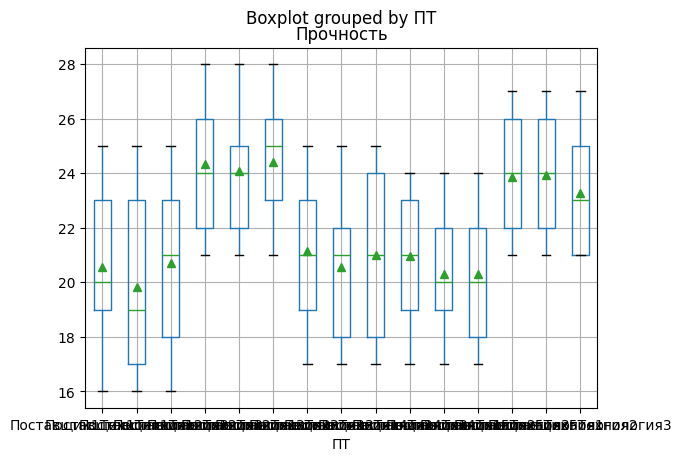

In [18]:
d.boxplot(column='Прочность', by='ПТ', showmeans=True)

array([[<Axes: title={'center': 'Поставщик1Технология1'}>,
        <Axes: title={'center': 'Поставщик1Технология2'}>,
        <Axes: title={'center': 'Поставщик1Технология3'}>,
        <Axes: title={'center': 'Поставщик2Технология1'}>],
       [<Axes: title={'center': 'Поставщик2Технология2'}>,
        <Axes: title={'center': 'Поставщик2Технология3'}>,
        <Axes: title={'center': 'Поставщик3Технология1'}>,
        <Axes: title={'center': 'Поставщик3Технология2'}>],
       [<Axes: title={'center': 'Поставщик3Технология3'}>,
        <Axes: title={'center': 'Поставщик4Технология1'}>,
        <Axes: title={'center': 'Поставщик4Технология2'}>,
        <Axes: title={'center': 'Поставщик4Технология3'}>],
       [<Axes: title={'center': 'Поставщик5Технология1'}>,
        <Axes: title={'center': 'Поставщик5Технология2'}>,
        <Axes: title={'center': 'Поставщик5Технология3'}>, <Axes: >]],
      dtype=object)

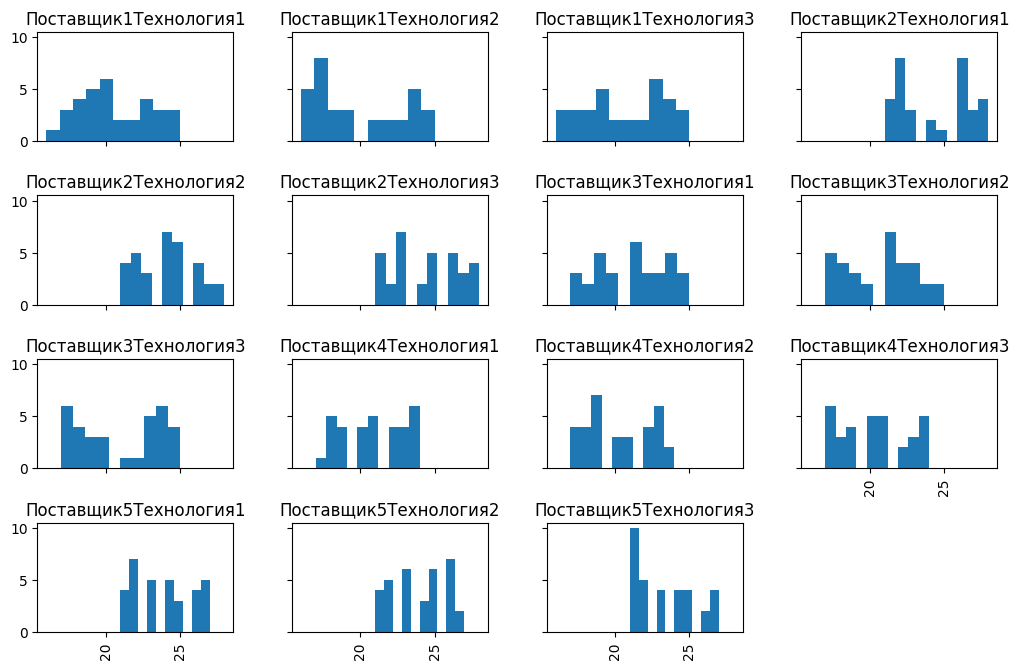

In [23]:
d.hist(column='Прочность', by='ПТ', sharex=True, sharey=True, figsize=(12, 8))

In [8]:
pg.normality(data=d, dv='Прочность', group='ПТ')

,W,pval,normal
ПТ,,,
Поставщик1Технология1,0.941923,0.077280,True
Поставщик1Технология2,0.855167,0.000443,False
Поставщик1Технология3,0.920858,0.019353,False
Поставщик2Технология1,0.883449,0.002037,False
Поставщик2Технология2,0.949803,0.131286,True
Поставщик2Технология3,0.926762,0.028323,False
Поставщик3Технология1,0.943460,0.085685,True
Поставщик3Технология2,0.938016,0.059495,True
Поставщик3Технология3,0.870179,0.000979,False


In [9]:
d['ПТ'].value_counts()

ПТ
Поставщик1Технология1    33
Поставщик1Технология2    33
Поставщик1Технология3    33
Поставщик2Технология1    33
Поставщик2Технология2    33
Поставщик2Технология3    33
Поставщик3Технология1    33
Поставщик3Технология2    33
Поставщик3Технология3    33
Поставщик4Технология1    33
Поставщик4Технология2    33
Поставщик4Технология3    33
Поставщик5Технология1    33
Поставщик5Технология2    33
Поставщик5Технология3    33
Name: count, dtype: int64

In [10]:
pg.homoscedasticity(data=d, dv='Прочность', group='ПТ')

,W,pval,equal_var
levene,3.031207,0.000167,False


In [11]:
pg.anova(data=d, dv='Прочность', between=['Поставщик','Технология'])

,Source,SS,DF,MS,F,p-unc,np2
0,Поставщик,1394.779798,4,348.694949,57.478386,1.272648e-39,0.323861
1,Технология,15.325253,2,7.662626,1.263097,2.837152e-01,0.005235
2,Поставщик * Технология,25.886869,8,3.235859,0.533394,8.315193e-01,0.008812
3,Residual,2911.939394,480,6.066540,NaN,NaN,NaN


In [25]:
pg.pairwise_tukey(data=d, dv='Прочность', between='Поставщик')

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,Поставщик1,Поставщик2,20.363636,24.282828,-3.919192,0.348933,-11.231928,5.040413e-13,-1.482686
1,Поставщик1,Поставщик3,20.363636,20.909091,-0.545455,0.348933,-1.563206,5.218293e-01,-0.193402
2,Поставщик1,Поставщик4,20.363636,20.525253,-0.161616,0.348933,-0.463172,9.905278e-01,-0.060727
3,Поставщик1,Поставщик5,20.363636,23.686869,-3.323232,0.348933,-9.523980,5.040413e-13,-1.303507
4,Поставщик2,Поставщик3,24.282828,20.909091,3.373737,0.348933,9.668721,5.040413e-13,1.371892
5,Поставщик2,Поставщик4,24.282828,20.525253,3.757576,0.348933,10.768756,5.040413e-13,1.651597
6,Поставщик2,Поставщик5,24.282828,23.686869,0.595960,0.348933,1.707948,4.299571e-01,0.278074
7,Поставщик3,Поставщик4,20.909091,20.525253,0.383838,0.348933,1.100034,8.065073e-01,0.154864
8,Поставщик3,Поставщик5,20.909091,23.686869,-2.777778,0.348933,-7.960774,6.240564e-13,-1.178013
9,Поставщик4,Поставщик5,20.525253,23.686869,-3.161616,0.348933,-9.060808,5.040413e-13,-1.460083
